# Задача 2. Змодельовані дані

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(42)

## Частина 1 (а) Забруднення вибірки

       mean  median     var
m                          
10   10.827  10.135   8.594
30   12.310  10.384  20.197
50   13.268  10.538  23.792
70   14.022  10.727  26.098
90   14.782  11.048  28.255
110  15.235  16.567  27.746
130  15.556  17.579  26.923
150  15.792  17.740  25.611
170  16.254  18.213  26.252
190  16.638  18.971  26.209


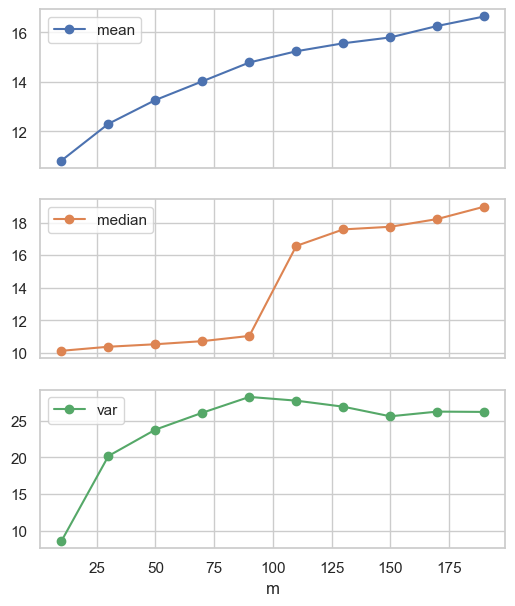

In [2]:
base = rng.normal(10, 1, 100)
rows = []
for m in range(10, 201, 20):
    all_ = np.concatenate([base, rng.normal(20, 2, m)])
    rows.append((m, all_.mean(), np.median(all_), all_.var(ddof=1)))
res = pd.DataFrame(rows, columns=["m", "mean", "median", "var"]).set_index("m")
print(res.round(3))
res.plot(subplots=True, marker="o", figsize=(6, 7)); plt.show()

Середнє росте монотонно від ≈10.8 до ≈16.6 (воно «тягнеться» до другої підвибірки пропорційно її частці). Медіана майже не реагує (≈10–11), поки m < n₁=100, а потім стрибком переходить у другу групу (≈16.6 при m=110, далі ≈19) — медіана стійка до малого забруднення, але чутлива до переходу «більшість». Вибіркова дисперсія спочатку різко росте (8.6 → ≈28 біля m≈90, коли групи майже рівні й центри далеко одне від одного), потім трохи спадає, бо домінує друга група. Висновок: зі зростанням неоднорідності середнє і дисперсія сильно спотворюються.

## (б) Box-plot та гістограми

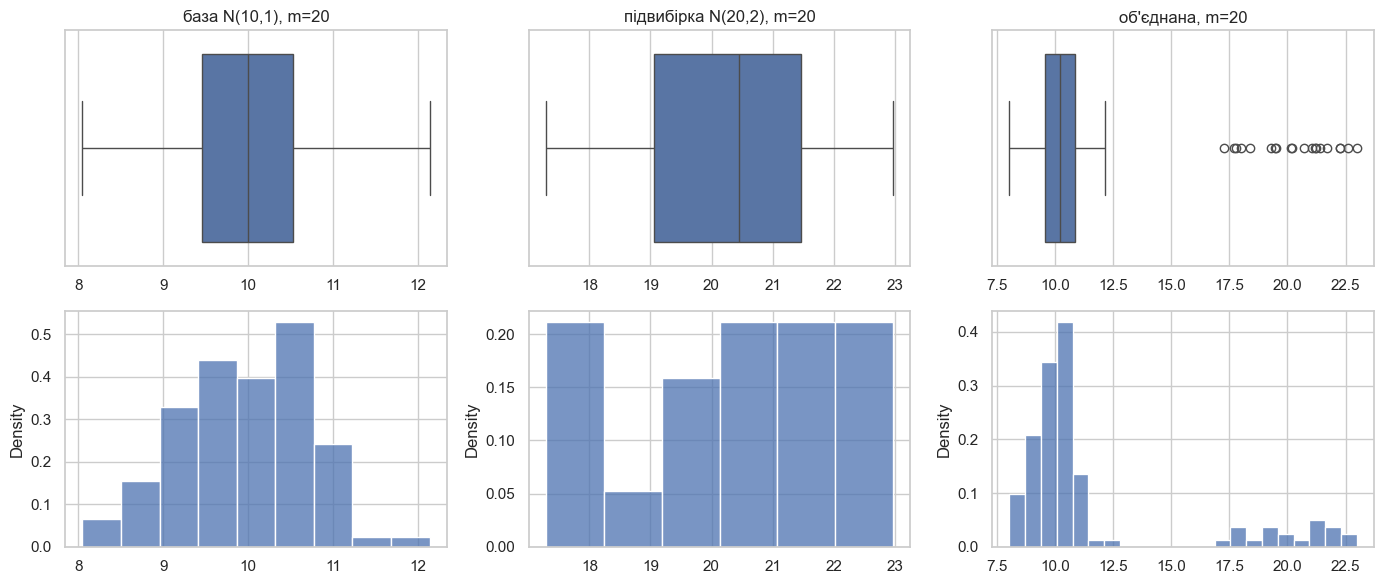

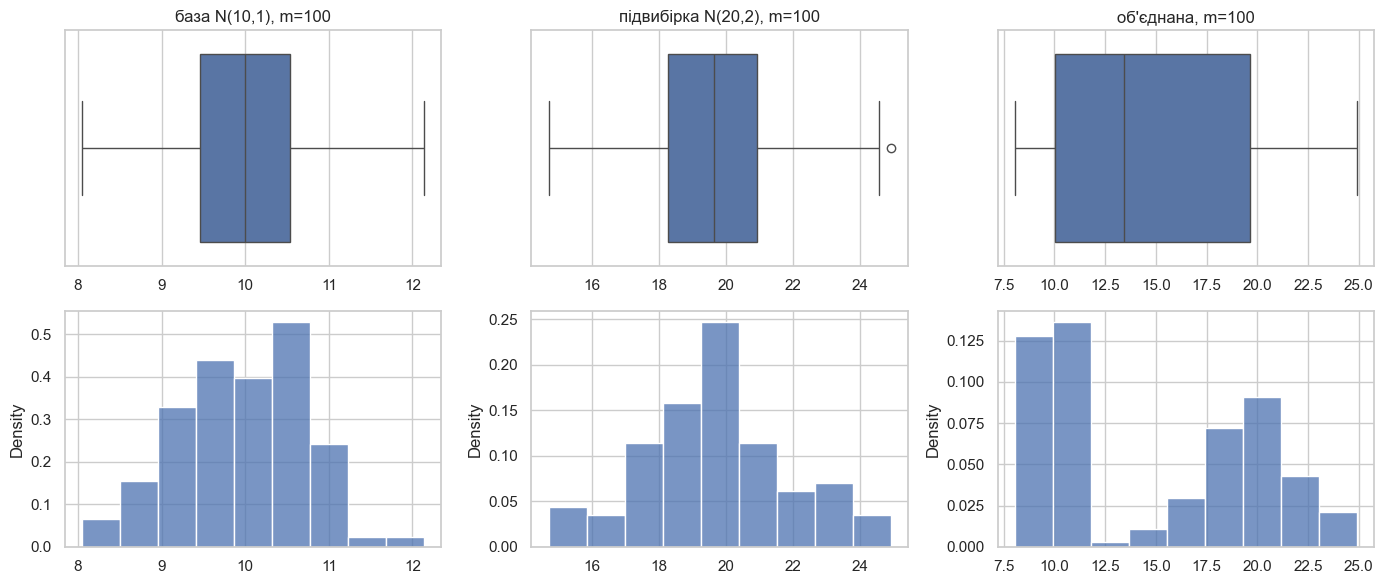

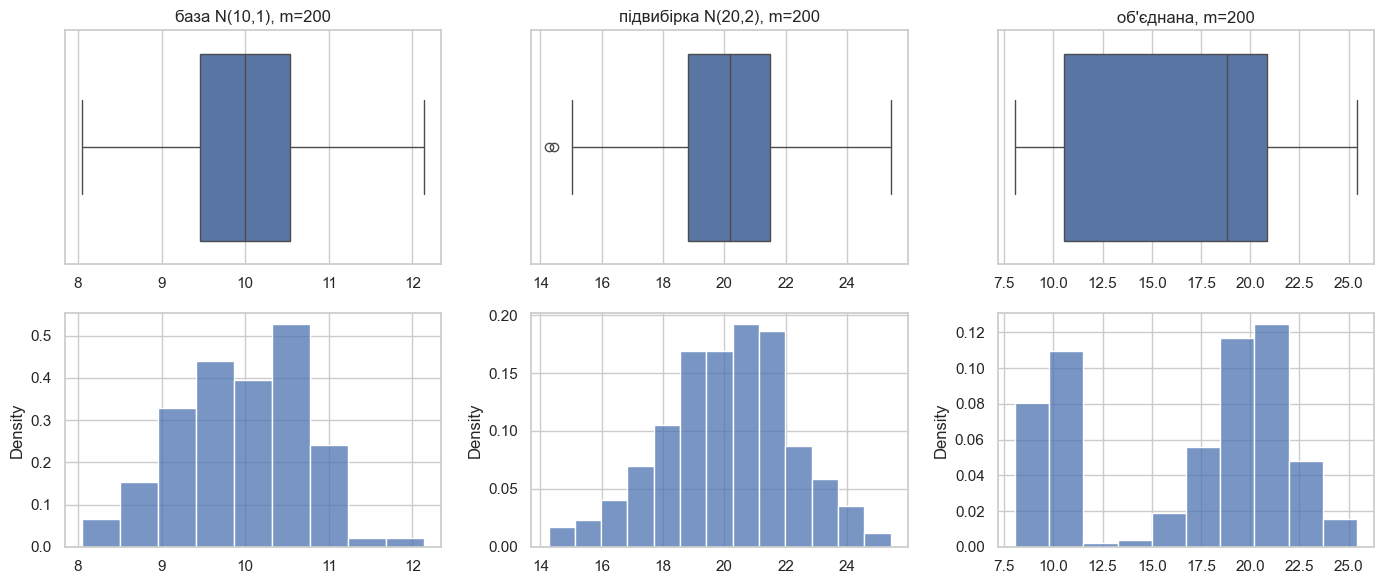

In [3]:
for m in [20, 100, 200]:
    sub = rng.normal(20, 2, m)
    all_ = np.concatenate([base, sub])
    fig, ax = plt.subplots(2, 3, figsize=(14, 6))
    for j, (d, name) in enumerate([(base, "база N(10,1)"), (sub, "підвибірка N(20,2)"), (all_, "об'єднана")]):
        sns.boxplot(x=d, ax=ax[0, j]); ax[0, j].set_title(f"{name}, m={m}")
        sns.histplot(d, stat="density", ax=ax[1, j])
    plt.tight_layout(); plt.show()

При m=20 об'єднана вибірка схожа на базову з правим «хвостом»/викидами. При m=100 з'являється дві моди (бімодальна гістограма), box-plot вже неінформативний. При m=200 домінує друга група, а базова стає лівим «хвостом». Тобто одна пара (середнє, std) погано описує неоднорідні дані.

## Частина 3 (а) Доведення

$U^*=U$, $V^*=\rho U+\sqrt{1-\rho^2}V$, $U,V$ незалежні, $N(0,1)$.

- $Var(U^*)=Var(U)=1$.
- $Var(V^*)=\rho^2 Var(U)+(1-\rho^2)Var(V)=\rho^2+1-\rho^2=1$ (бо $Cov(U,V)=0$).
- $Cov(U^*,V^*)=Cov(U,\rho U+\sqrt{1-\rho^2}V)=\rho Var(U)+\sqrt{1-\rho^2}Cov(U,V)=\rho$.
- $Corr(U^*,V^*)=\dfrac{\rho}{\sqrt{1\cdot 1}}=\rho$. ∎

## (б) Вибіркові Пірсон і Спірмен

   rho  pearson  spearman
0 -0.9   -0.907    -0.886
1 -0.7   -0.733    -0.706
2 -0.5   -0.540    -0.520
3 -0.3   -0.254    -0.269
4 -0.1    0.003    -0.006
5  0.1   -0.074    -0.067
6  0.3    0.399     0.353
7  0.5    0.485     0.511
8  0.7    0.698     0.696
9  0.9    0.912     0.904


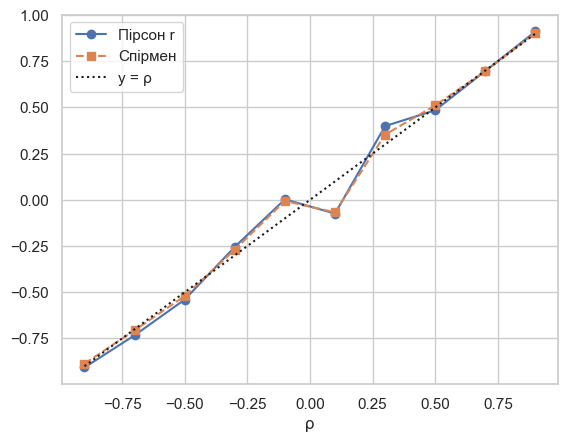

In [4]:
rhos = np.round(np.arange(-0.9, 0.91, 0.2), 1)
def gen(rho, n=100):
    U, V = rng.normal(size=n), rng.normal(size=n)
    return U, rho * U + np.sqrt(1 - rho**2) * V
out = []
for r in rhos:
    U, V = gen(r)
    out.append((r, stats.pearsonr(U, V)[0], stats.spearmanr(U, V)[0]))
out = pd.DataFrame(out, columns=["rho", "pearson", "spearman"])
print(out.round(3))
plt.plot(out.rho, out.pearson, "o-", label="Пірсон r")
plt.plot(out.rho, out.spearman, "s--", label="Спірмен")
plt.plot(out.rho, out.rho, "k:", label="y = ρ")
plt.xlabel("ρ"); plt.legend(); plt.show()

Обидва коефіцієнти близькі до теоретичного ρ (відхилення — вибіркова похибка при n=100); Спірмен трохи менший за модулем, але поводиться так само, бо залежність лінійна.

## (в) Експоненційне перетворення

   rho  pearson V  pearson exp(V)  spearman V  spearman exp(V)
0 -0.9     -0.893          -0.773      -0.883           -0.883
1 -0.5     -0.542          -0.371      -0.557           -0.557
2  0.5      0.515           0.441       0.490            0.490
3  0.9      0.889           0.687       0.840            0.840


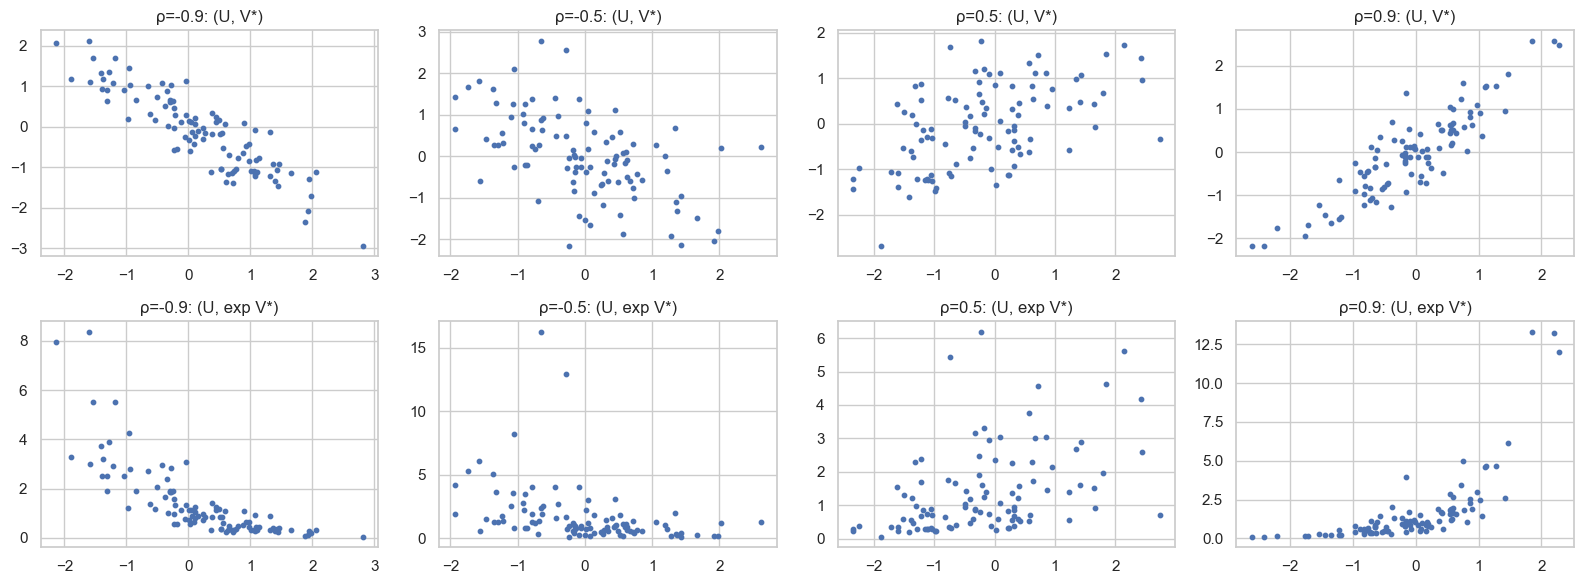

In [5]:
rows, fig_data = [], {}
for r in [-0.9, -0.5, 0.5, 0.9]:
    U, V = gen(r)
    Ve = np.exp(V)
    rows.append((r, stats.pearsonr(U, V)[0], stats.pearsonr(U, Ve)[0],
                 stats.spearmanr(U, V)[0], stats.spearmanr(U, Ve)[0]))
    fig_data[r] = (U, V, Ve)
print(pd.DataFrame(rows, columns=["rho", "pearson V", "pearson exp(V)", "spearman V", "spearman exp(V)"]).round(3))
fig, ax = plt.subplots(2, 4, figsize=(16, 6))
for j, (r, (U, V, Ve)) in enumerate(fig_data.items()):
    ax[0, j].scatter(U, V, s=10); ax[0, j].set_title(f"ρ={r}: (U, V*)")
    ax[1, j].scatter(U, Ve, s=10); ax[1, j].set_title(f"ρ={r}: (U, exp V*)")
plt.tight_layout(); plt.show()

Спірмен **не змінюється** після exp(V*), бо exp — строго зростаюча функція і ранги збережені. Пірсон падає за модулем: зв'язок стає нелінійним, а великі значення exp(V*) діють як викиди. Економічно: якщо залежність між змінними монотонна, але нелінійна (наприклад, дохід і витрати на розкіш, обсяги й ціни зі скошеними розподілами), Спірмен надійніший, а Пірсон може недооцінити силу зв'язку.